In [ ]:
%pip install pandas
%pip install scikit-learn
%pip install imbalanced-learn

In [ ]:
import pandas as PANDAS

In [ ]:
# RANDOM FOREST MODEL

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report


from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [ ]:
DATA = PANDAS.read_csv('/content/FInal Data.csv', encoding='utf-8')

X = DATA.drop(columns=['Voldaan (J=1/N=0)'])
y = DATA ['Voldaan (J=1/N=0)']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.1, random_state = 47, stratify = y)

In [ ]:
pipeline = Pipeline([
    # the other models include a scaler function here, is there a reason why not with this one?
    ('smote', SMOTE(random_state=47)),
    ('rf', RandomForestClassifier(class_weight='balanced',random_state=47))
])

In [ ]:
# PARAMETER GRID

param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 5, 10],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2],
    'rf__class_weight': [None, 'balanced']
}

# 10-FOLD CV
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=47)

# GRID SEARCH
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring= {"f1": "f1", "roc_auc": "roc_auc"},
    refit = "roc_auc",
    n_jobs = -1
    )

 # TRAIN

grid_search.fit(X_train, y_train)

In [ ]:
# could you also maybe include a printed version of more info? For example like below (from other models)

RESULTS = PANDAS.DataFrame(grid_search.cv_results_)

print("Top 5 Models by ROC AUC:")
print(
    RESULTS[['params', 'mean_test_roc_auc', 'mean_test_f1']]
    .sort_values(by='mean_test_roc_auc', ascending=False)
    .head(5)
)

print("\nBest parameters:", grid_search.best_params_)
print("Best CV score (ROC-AUC):", grid_search.best_score_)

BEST_MODEL = grid_search.best_estimator_

importances = BEST_MODEL.named_steps['rf'].feature_importances_

feature_importance = PANDAS.Series(importances, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.to_string())

In [ ]:
y_pred = BEST_MODEL.predict(X_test)

In [ ]:
# Predictions
y_pred = grid_search.best_estimator_.predict(X_test)

# Probabilities (needed for ROC-AUC)
y_proba = grid_search.best_estimator_.predict_proba(X_test)[:, 1]


# Accuracy
ACCURACY = accuracy_score(y_test, y_pred)
print(f"accuracy: {round(ACCURACY, 2)}")


# Confusion Matrix
CM = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", CM)


# Precision
PRECISION = precision_score(y_test, y_pred, zero_division=0)
print(f"Precision: {round(PRECISION, 2)}")


# Recall
RECALL = recall_score(y_test, y_pred, zero_division=0)
print(f"Recall: {round(RECALL, 2)}")


# F1 Score
F1 = f1_score(y_test, y_pred)
print(f"f1 score: {round(F1, 2)}")


# ROC-AUC (extra compared to SVM block)
ROC_AUC = roc_auc_score(y_test, y_proba)
print(f"ROC AUC: {round(ROC_AUC, 2)}")


# Full report
print(classification_report(y_test, y_pred))

In [ ]:
%pip install matplotlib # helps visualise data and results

In [ ]:
import matplotlib.pyplot as MATPLOTLIB

In [ ]:
RESULTS = PANDAS.DataFrame (grid_search.cv_results_)

print ("Top 3 Models by ROC AUC:")
print (RESULTS [['params', 'mean_test_roc_auc', 'mean_test_f1']].sort_values(by='mean_test_roc_auc', ascending = False).head(3))

print (RESULTS["mean_test_f1"])
print (RESULTS["mean_test_roc_auc"])
print (RESULTS ["params"])
print ("Best parameters:", grid_search.best_params_)
print ("Best CV score:", grid_search.best_score_)

BEST_MODEL = grid_search.best_estimator_

In [ ]:
# in this step we will be calculating the ROC-AUC (shows how well the model separates classes across thresholds)
# measures ranking ability, not exact predictions --> higher value means better class separation
# the following code should output a table

from sklearn.metrics import roc_curve

y_prob = BEST_MODEL.predict_proba (X_test)[:, 1]

fpr, tpr, thresholds = roc_curve (y_test, y_prob)

roc_auc = roc_auc_score (y_test, y_prob)
print(f"ROC AUC: {round(roc_auc, 2)}")

MATPLOTLIB.figure ()
MATPLOTLIB.plot (fpr, tpr, label = f"ROC Curve (AUC = {roc_auc:.2f})")
MATPLOTLIB.plot ([0, 1], [0, 1], linestyle = "--", label = "Random")
MATPLOTLIB.xlabel ("False Positive Rate")
MATPLOTLIB.ylabel ("True Positive Rate")
MATPLOTLIB.title ("ROC Curve")
MATPLOTLIB.legend ()
MATPLOTLIB.show ()

In [ ]:
%pip install shap

### Interpreting Model Parameters with SHAP Values

Since Random Forest models do not provide coefficients like linear models, SHAP (SHapley Additive exPlanations) values offer a way to understand the impact and direction of each feature on individual predictions. This helps to explain why the model made a particular prediction for an instance.

Here, we will calculate and visualize SHAP values for the test set. The summary plot below will show the importance of each feature and, for each feature, how its values (color-coded from low to high) impact the prediction (whether they push the prediction higher or lower).

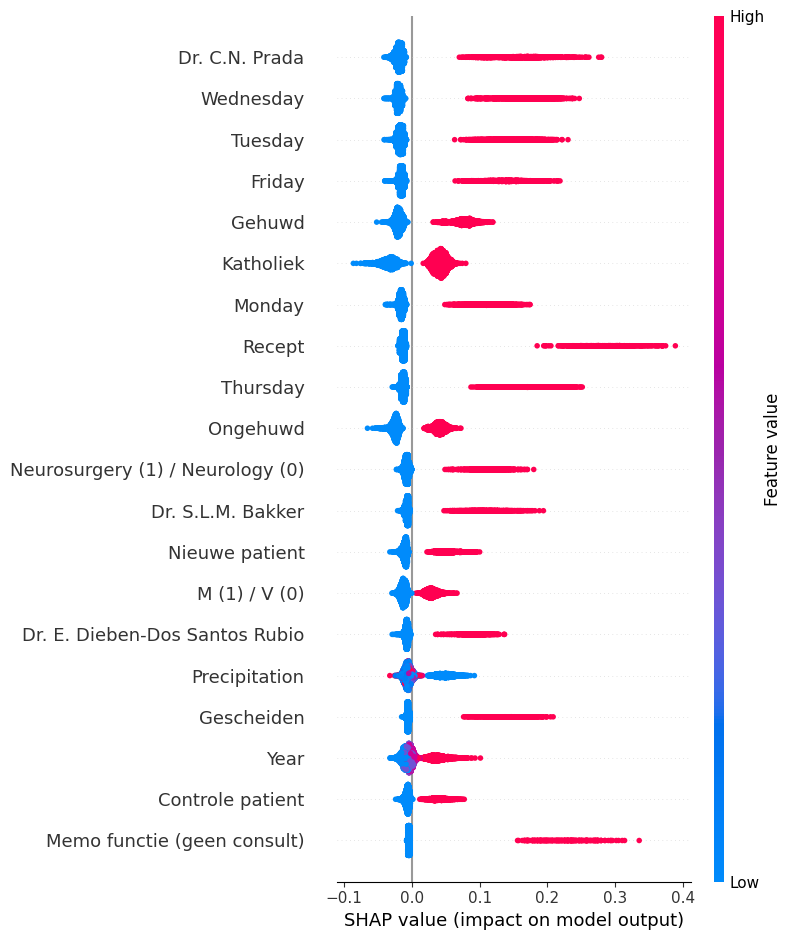

In [18]:
import shap

# Initialize a TreeExplainer with the best Random Forest model
explainer = shap.TreeExplainer(BEST_MODEL.named_steps['rf'])

# Calculate SHAP values for the test set
# Since SMOTE was used on the training data, we should be careful with directly explaining X_test
# However, for demonstration purposes and general feature understanding, it's common to explain X_test.
shap_values = explainer.shap_values(X_test)

# Summarize the feature importances with a summary plot
# shap_values is a list of arrays for multi-output. For binary classification, shap_values[1] typically refers to the positive class.
# Correction: For TreeExplainer, shap_values is a 3D array (samples, features, outputs). To get shap values for the positive class (index 1) across all samples, use shap_values[:, :, 1].
shap.summary_plot(shap_values[:, :, 1], X_test)

In [ ]:
import shap # Added to ensure shap is imported

# Ensure BEST_MODEL is defined. This line assumes 'grid_search' is already defined and fitted from previous cells.
# If 'grid_search' is also not defined, please ensure all cells up to model training have been executed.
BEST_MODEL = grid_search.best_estimator_

# Initialize a TreeExplainer with the best Random Forest model (re-added for self-containment)
explainer = shap.TreeExplainer(BEST_MODEL.named_steps['rf'])

# Calculate SHAP values for the test set (re-added for self-containment)
shap_values = explainer.shap_values(X_test)

# Extract SHAP values for the positive class (index 1)
shap_values_positive_class = shap_values[:, :, 1]

# Create a DataFrame for SHAP values with feature names
shap_df = PANDAS.DataFrame(shap_values_positive_class, columns=X_test.columns)

# Calculate the mean SHAP value for each feature
mean_shap_values = shap_df.mean()

# Filter for features with negative mean SHAP values
negative_shap_features = mean_shap_values[mean_shap_values < 0]

# Sort the features by their negative SHAP values for better readability
negative_shap_features_sorted = negative_shap_features.sort_values(ascending=True)

print("Features with Negative Mean SHAP Values (reducing likelihood of 'Voldaan J=1'):")
print(negative_shap_features_sorted.to_string())